# E-Commerce Sales Analysis
### Superstore Dataset — 9,994 Orders (2014–2017)

## Project Overview
Analysed 4 years of retail sales data to identify revenue trends,
regional performance, product insights and the impact of discounting
on profitability.

## Tools Used
Python | Pandas | Matplotlib | Seaborn | Jupyter Notebook

## Key Findings
1. Sales grew consistently year over year with strong Q4 seasonal peaks
2. Technology is the highest revenue category driven by Phones
3. All 4 regions are profitable with West leading and Central lagging
4. Discounts above 40% almost always result in losses — 
   this is the biggest threat to profitability
5. Consumer segment holds 50.6% of sales but Home Office 
   and Corporate have the most growth potential

## Business Recommendations
1. Cap discounts at 20% maximum to protect profit margins
2. Increase inventory before Q4 every year to maximize peak season
3. Target Home Office segment with furniture promotions
4. Investigate why Central region underperforms other regions

In [10]:
import pandas as pd

In [13]:
df = pd.read_csv('Superstore sales dataset.csv')
print(df.shape)   # Should show (9994, 21)
df.head()         # Shows first 5 rows


(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,12/6/2016,16/6/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [14]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 9994
Columns: 21


In [15]:
for col in df.columns:
    print(col)

Row ID
Order ID
Order Date
Ship Date
Ship Mode
Customer ID
Customer Name
Segment
Country
City
State
Postal Code
Region
Product ID
Category
Sub-Category
Product Name
Sales
Quantity
Discount
Profit


In [38]:
df.iloc[0:5, 5:10]


,Customer ID,Customer Name,Segment,Country,City
0,CG-12520,Claire Gute,Consumer,United States,Henderson
1,CG-12520,Claire Gute,Consumer,United States,Henderson
2,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles
3,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale
4,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale


In [26]:
important = ['Order Date', 'Category', 'Sub-Category', 'Region', 'Segment', 'Sales', 'Profit', 'Discount']
df[important].head(10)

,Order Date,Category,Sub-Category,Region,Segment,Sales,Profit,Discount
0,8/11/2016,Furniture,Bookcases,South,Consumer,261.9600,41.9136,0.00
1,8/11/2016,Furniture,Chairs,South,Consumer,731.9400,219.5820,0.00
2,12/6/2016,Office Supplies,Labels,West,Corporate,14.6200,6.8714,0.00
3,11/10/2015,Furniture,Tables,South,Consumer,957.5775,-383.0310,0.45
4,11/10/2015,Office Supplies,Storage,South,Consumer,22.3680,2.5164,0.20
5,9/6/2014,Furniture,Furnishings,West,Consumer,48.8600,14.1694,0.00
6,9/6/2014,Office Supplies,Art,West,Consumer,7.2800,1.9656,0.00
7,9/6/2014,Technology,Phones,West,Consumer,907.1520,90.7152,0.20
8,9/6/2014,Office Supplies,Binders,West,Consumer,18.5040,5.7825,0.20
9,9/6/2014,Office Supplies,Appliances,West,Consumer,114.9000,34.4700,0.00


In [33]:
print(df.dtypes)  

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [37]:
df['Sales'][2:10]

2     14.6200
3    957.5775
4     22.3680
5     48.8600
6      7.2800
7    907.1520
8     18.5040
9    114.9000
Name: Sales, dtype: float64

In [60]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Year'] = df['Order Date'].dt.to_period('M')

print("✓ Done! Here's a preview:")
print(df[['Order Date', 'Year', 'Month', 'Month_Year']].head())

✓ Done! Here's a preview:
  Order Date  Year  Month Month_Year
0 2016-11-08  2016     11    2016-11
1 2016-11-08  2016     11    2016-11
2 2016-06-12  2016      6    2016-06
3 2015-10-11  2015     10    2015-10
4 2015-10-11  2015     10    2015-10


In [57]:
df[['Sales', 'Profit', 'Discount']].describe().round(2)

,Sales,Profit,Discount
count,9994.00,9994.00,9994.00
mean,229.86,28.66,0.16
std,623.25,234.26,0.21
min,0.44,-6599.98,0.00
25%,17.28,1.73,0.00
50%,54.49,8.67,0.20
75%,209.94,29.36,0.20
max,22638.48,8399.98,0.80


In [58]:
print("Missing values in each column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values in each column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Year             0
Month            0
Month_Year       0
dtype: int64

Duplicate rows: 0


In [61]:
df[['Sales', 'Profit', 'Discount']].describe().round(2)

,Sales,Profit,Discount
count,9994.00,9994.00,9994.00
mean,229.86,28.66,0.16
std,623.25,234.26,0.21
min,0.44,-6599.98,0.00
25%,17.28,1.73,0.00
50%,54.49,8.67,0.20
75%,209.94,29.36,0.20
max,22638.48,8399.98,0.80


In [62]:
import os
os.makedirs('charts', exist_ok=True)
print("charts folder created!")

charts folder created!


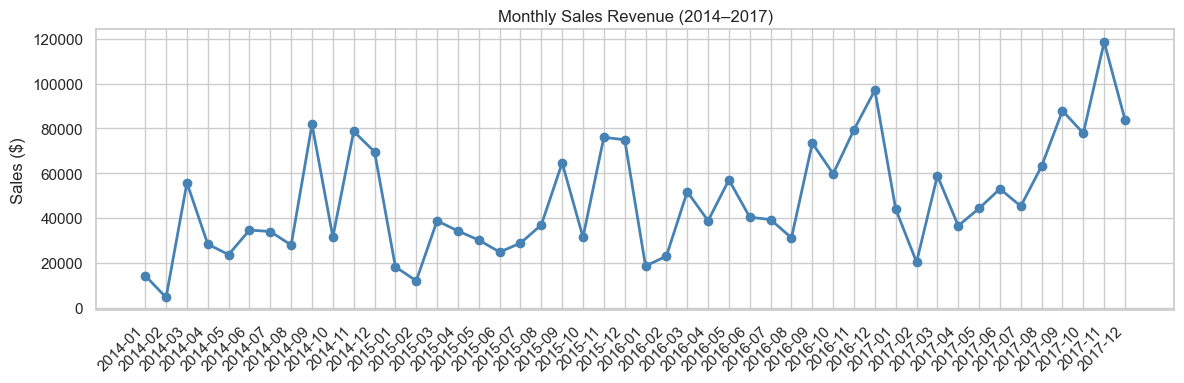

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# This sets a clean visual style for all charts
sns.set_theme(style='whitegrid')

# Group all orders by month and add up the sales
monthly_sales = df.groupby('Month_Year')['Sales'].sum().reset_index()
monthly_sales['Month_Year'] = monthly_sales['Month_Year'].astype(str)

# Draw the chart
plt.figure(figsize=(12, 4))
plt.plot(monthly_sales['Month_Year'], monthly_sales['Sales'], 
         marker='o', color='steelblue', linewidth=2)
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Sales Revenue (2014–2017)')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('charts/01_monthly_sales.png', dpi=150)
plt.show()

## Chart 1 Insight — Monthly Sales Trend

Sales show consistent year-over-year growth from 2014 to 2017.
A clear seasonal pattern exists with peaks in Q4 (Oct–Dec) every year,
likely driven by holiday shopping. Lowest sales occur in Q1 (Jan–Feb).

Recommendation: The business should increase inventory and 
marketing spend before Q4 every year to maximize the peak season.

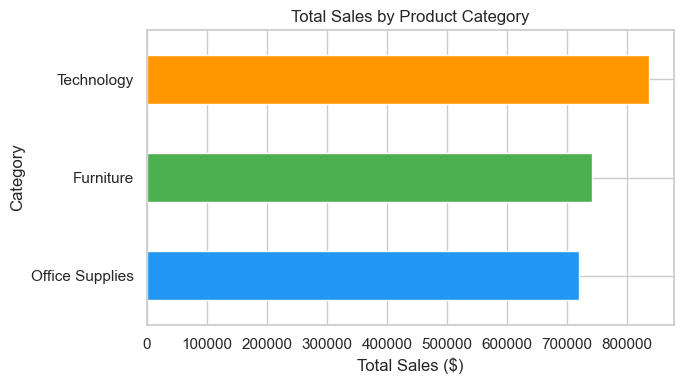

In [67]:
# Add up total sales for each category
category_sales = df.groupby('Category')['Sales'].sum().sort_values()

# Draw the chart
plt.figure(figsize=(7, 4))
category_sales.plot(kind='barh', color=['#2196F3','#4CAF50','#FF9800'])
plt.title('Total Sales by Product Category')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('charts/02_category_sales.png', dpi=150)
plt.show()

## Chart 2 Insight — Sales by Category

Technology is the highest revenue category, followed by Furniture,
then Office Supplies. However high sales does not always mean high
profit — further analysis of profit by category is needed before
drawing conclusions about which category is most valuable to the business.

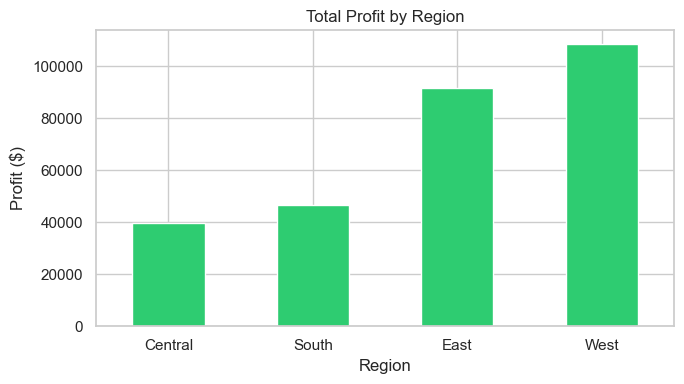

In [70]:
# Add up total profit for each region
region_profit = df.groupby('Region')['Profit'].sum().sort_values()

# Draw the chart
plt.figure(figsize=(7, 4))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in region_profit]
region_profit.plot(kind='bar', color=colors)
plt.title('Total Profit by Region')
plt.ylabel('Profit ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('charts/03_region_profit.png', dpi=150)
plt.show()

## Chart 3 Insight — Profit by Region

All 4 regions are profitable which is a healthy sign.
The West region leads in profitability while Central 
region lags behind the others. Further investigation 
is needed to understand why Central underperforms —
possible causes include higher discounting rates or 
higher operating costs in that region.

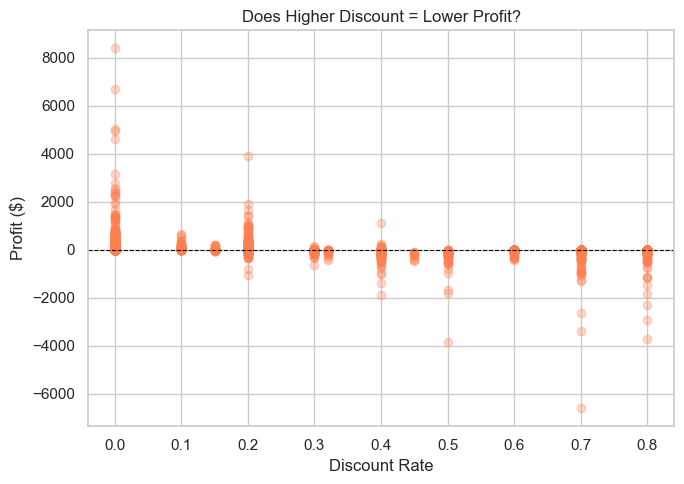

In [73]:
plt.figure(figsize=(7, 5))
plt.scatter(df['Discount'], df['Profit'], 
            alpha=0.3, color='coral')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Does Higher Discount = Lower Profit?')
plt.xlabel('Discount Rate')
plt.ylabel('Profit ($)')
plt.tight_layout()
plt.savefig('charts/04_discount_profit.png', dpi=150)
plt.show()

## Chart 4 Insight — Discount vs Profit

There is a clear negative relationship between discount 
and profit. Orders with discounts above 40% almost always 
result in losses for the company. The majority of unprofitable 
orders (below the zero line) are concentrated on the right 
side of the chart where discounts are highest.

Recommendation: Cap discounts at 20% maximum to protect 
profit margins. Heavy discounting is the single biggest 
cause of losses in this business.

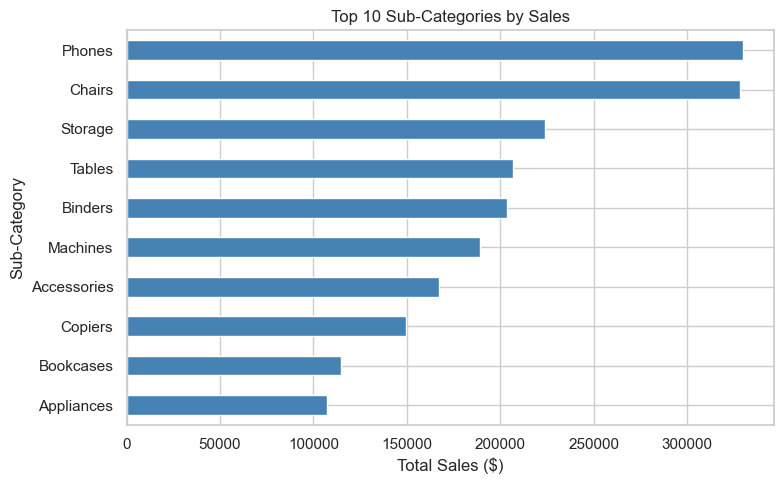

In [74]:
# Get top 10 sub-categories by total sales
top_subcategories = df.groupby('Sub-Category')['Sales'].sum().nlargest(10)

# Draw the chart
plt.figure(figsize=(8, 5))
top_subcategories.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Sub-Categories by Sales')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('charts/05_top_subcategories.png', dpi=150)
plt.show()

## Chart 5 Insight — Top 10 Sub-Categories by Sales

Phones is the single highest revenue sub-category, consistent
with Technology being the top category overall. Chairs rank
second showing Furniture has some strong individual products
despite being second overall. Notably some Office Supplies
sub-categories appear in the top 10 driven by high volume
of orders rather than high price per item.

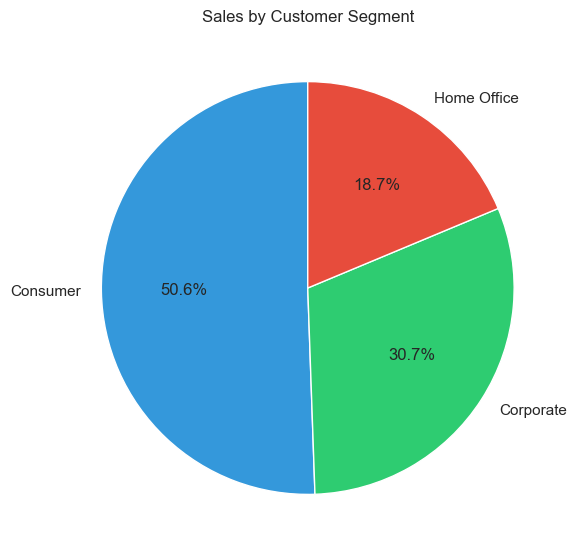

In [78]:
# Add up sales for each customer segment
segment_sales = df.groupby('Segment')['Sales'].sum()

# Draw the chart
plt.figure(figsize=(6, 6))
plt.pie(segment_sales, 
        labels=segment_sales.index, 
        autopct='%1.1f%%',
        colors=['#3498db','#2ecc71','#e74c3c'],
        startangle=90)
plt.title('Sales by Customer Segment')
plt.tight_layout()
plt.savefig('charts/06_segment_pie.png', dpi=150)
plt.show()

## Chart 6 Insight — Customer Segment

Consumer segment dominates with 50.6% of total sales followed 
by Corporate at 30.7% and Home Office at 18.7%.

Recommendation: Focus growth efforts on Home Office and Corporate 
segments as they have the most room to grow. Since Chairs and Tables 
already rank highly in top 10 sub-categories, targeted furniture 
promotions toward Home Office customers could significantly increase 
revenue as these customers are actively setting up workspaces.